<h2>🚀 Intrusion Detection Model Training on CICIDS 2017 Dataset </h2>

<p>
This notebook demonstrates a full workflow on the <b>CICIDS2017 dataset</b>, 
covering preprocessing, scaling, training, and evaluating multiple ML models.
</p>

<h3>Steps covered:</h3>
<ol>
  <li>Data Loading</li>
  <li>Data Cleaning (missing values, duplicates)</li>
  <li>Target Label Creation and Class Distribution Plot</li>
  <li> Feature Encoding for Categorical Columns</li>
  <li>Feature Scaling</li>
  <li> Prepare Features and Target</li>
  <li>Model Training and Evaluation on various models</li>
  <li>Visualization: Accuracy Barplot, Confusion Matrix, ROC Curve</li>
</ol>


<h3>Step 1: Data Loading</h3>

In [15]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score


file_path = '../data/DoS-Wednesday-no-metadata.parquet'

# Load dataset
df = pd.read_parquet(file_path)
print("Dataset shape:", df.shape)
print(df.head())


Dataset shape: (584991, 78)
   Protocol  Flow Duration  Total Fwd Packets  Total Backward Packets  \
0         6          38308                  1                       1   
1         6            479                 11                       5   
2         6           1095                 10                       6   
3         6          15206                 17                      12   
4         6           1092                  9                       6   

   Fwd Packets Length Total  Bwd Packets Length Total  Fwd Packet Length Max  \
0                         6                         6                      6   
1                       172                       326                     79   
2                      3150                      3150                   1575   
3                      3452                      6660                   1313   
4                      3150                      3152                   1575   

   Fwd Packet Length Min  Fwd Packet Length Mean  Fw

<h3>Step 2: Data Cleaning</h3>

In [3]:
# Check and drop missing values if any
print("Missing values in dataset:", df.isnull().sum().sum())
df.dropna(inplace=True)

# Remove duplicates
before = df.shape[0]
df.drop_duplicates(inplace=True)
print(f"Removed {before - df.shape[0]} duplicates. New shape: {df.shape}")

Missing values in dataset: 0
Removed 0 duplicates. New shape: (584991, 78)


<h3> Step 3: Target Label Creation and Distribution Plot</h3>

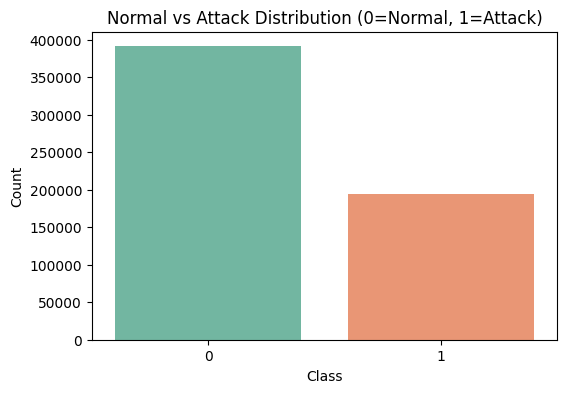

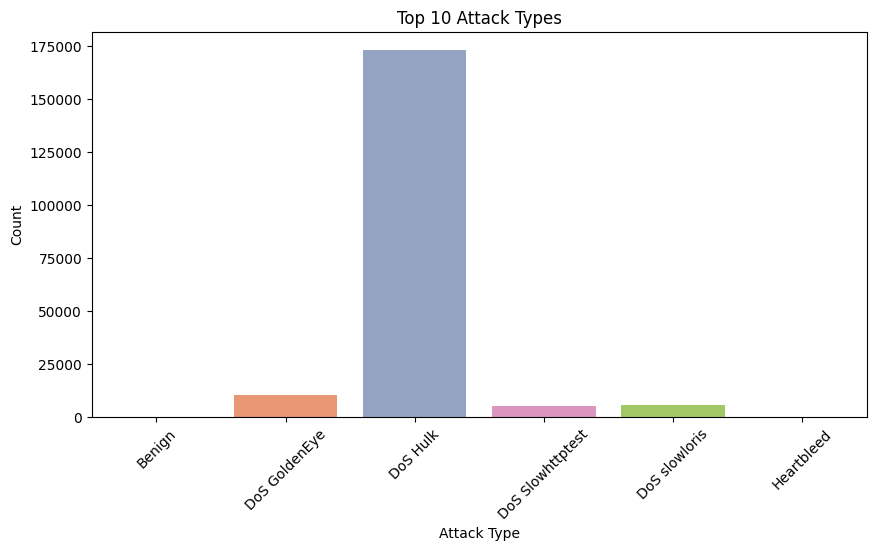

In [5]:
# Create binary target variable: 0 = Benign, 1 = Attack 
df['attack_binary'] = df['Label'].apply(lambda x: 0 if str(x).lower() == 'benign' else 1)

# Plot class distribution 
plt.figure(figsize=(6,4))
sns.countplot(x='attack_binary', hue='attack_binary', data=df, palette="Set2", dodge=False, legend=False)
plt.title("Normal vs Attack Distribution (0=Normal, 1=Attack)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# Top 10 attack types plot 
attack_counts = df[df['Label'].str.lower() != 'benign']['Label'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=attack_counts.index, y=attack_counts.values, hue=attack_counts.index, palette="Set2", dodge=False, legend=False)
plt.title("Top 10 Attack Types")
plt.xlabel("Attack Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


<h3>Step 4: Feature Encoding</h3>

In [6]:
# Identify categorical columns except 'Label' and target
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols = [col for col in categorical_cols if col not in ['Label', 'attack_binary']]

# One-hot encode categorical columns
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)


<h3>Step 5: Feature Scaling</h3>

In [7]:
exclude_cols = ['Label', 'attack_binary']
numeric_cols = df.select_dtypes(include=np.number).columns.difference(exclude_cols)

scaler = MinMaxScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

<h3>Step 6: Prepare Features and Target</h3>

In [9]:
X = df.drop(columns=exclude_cols)
y = df['attack_binary']

# Train-test split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Train set:", X_train.shape)
print("Test set:", X_test.shape)


Train set: (467992, 77)
Test set: (116999, 77)


<h3>Step 7: Model Training and Evaluation</h3>

In [10]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=120, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results = {}
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc * 100:.2f}%")
    print(classification_report(y_test, y_pred, target_names=["Normal", "Attack"]))



Training Logistic Regression...
Logistic Regression Accuracy: 97.15%
              precision    recall  f1-score   support

      Normal       0.97      0.99      0.98     78248
      Attack       0.98      0.94      0.96     38751

    accuracy                           0.97    116999
   macro avg       0.97      0.96      0.97    116999
weighted avg       0.97      0.97      0.97    116999


Training Decision Tree...
Decision Tree Accuracy: 99.91%
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     78248
      Attack       1.00      1.00      1.00     38751

    accuracy                           1.00    116999
   macro avg       1.00      1.00      1.00    116999
weighted avg       1.00      1.00      1.00    116999


Training Random Forest...
Random Forest Accuracy: 99.87%
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     78248
      Attack       1.00      1.00      1.00     387

<h3>Step 8: Visualization of Results</h3>

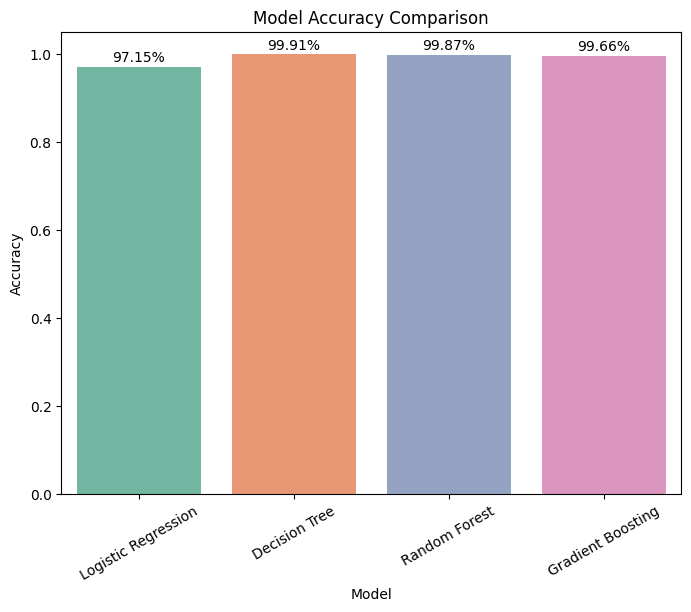

In [14]:
# Accuracy barplot
results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])

plt.figure(figsize=(8,6))
barplot = sns.barplot(x='Model', y='Accuracy', hue='Model', data=results_df, dodge=False, palette="Set2", legend=False)
plt.title('Model Accuracy Comparison')
plt.ylim(0, 1.05)
plt.xticks(rotation=30)

for bar in plt.gca().patches:
    height = bar.get_height()
    plt.gca().text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        f"{height * 100:.2f}%",
        ha='center'
    )
plt.show()


<h3>Step 9: Confusion matrix for best model</h3>

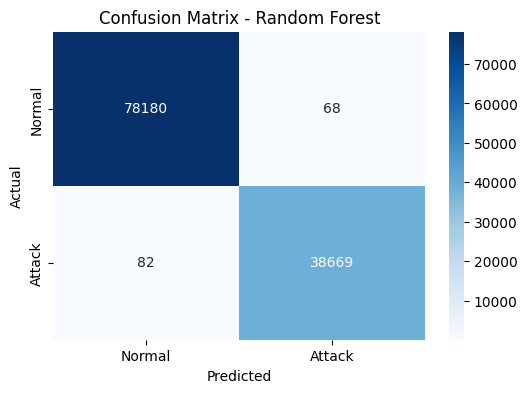

Confusion Matrix Accuracy: 99.87%


In [11]:
best_model = models['Random Forest']
y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'])
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

accuracy_from_cm = (cm[0,0] + cm[1,1]) / cm.sum()
print(f"Confusion Matrix Accuracy: {accuracy_from_cm * 100:.2f}%")

<h3> Step 10: ROC Curve for all models</h3>

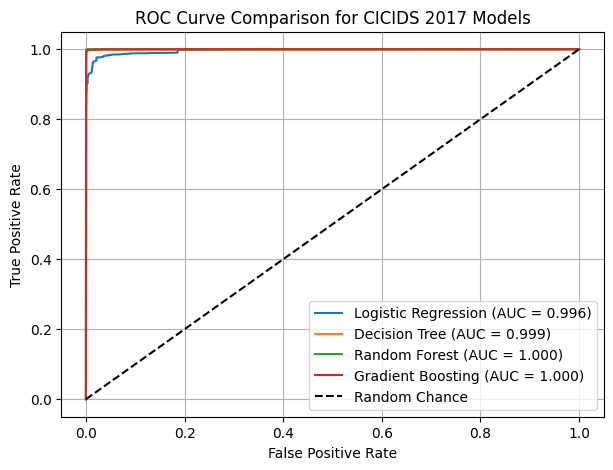

In [13]:
plt.figure(figsize=(7, 5))
for name, model in models.items():
    y_probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    auc_score = roc_auc_score(y_test, y_probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.title('ROC Curve Comparison for CICIDS 2017 Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()